# Deteção de Outliers com Métodos de Aprendizagem Não Supervisionada (MANS)

Serão utilizadas duas abordagens:

- **K-Means** Algoritmo de clustering que agrupa observações semelhantes em K clusters com base na distância aos centróides.
- **DBSCAN** Algoritmo baseado em densidade que identifica clusters e classifica pontos isolados como ruído (outliers).



 Imports e carregamento de dados

In [53]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import calinski_harabasz_score
from sklearn.metrics import davies_bouldin_score
from sklearn.cluster import DBSCAN



file_path = "contratos_limpo.csv"
df = pd.read_csv(file_path, low_memory=False)

# produzidos no fim de Outliers_.ipynb
df_outliers = pd.read_pickle("df_outliers.pkl")


In [54]:
len(df)

1803493

## Features utlizadas

| Feature                       | Justificação                                               |
|-------------------------------|------------------------------------------------------------|
| `precoContratual_2025`        | Valor do contrato em euros constantes                      |
| `prazoExecucao`               | Duração em dias                                            |
| `num_concorrentes`            | Número de empresas concorrentes                            |
| `is_ajuste_direto`            | Adjudicação sem concurso público (0/1)                     |
| `dias_publicacao_adjudicacao` | Dias entre publicação e decisão de adjudicação do contrato |

Nota: `racio_preco_prazo` não é incluído por ser uma função linear das duas primeiras features.

### Construção das features adicionais


In [55]:
# número de concorrentes
df["num_concorrentes"] = (
    df["concorrentes"].fillna("").astype(str)
    .str.split("\n")
    .apply(lambda lst: sum(1 for x in lst if x.strip() != ""))
)

# is_ajuste_direto
df["is_ajuste_direto"] = (
    df["tipoprocedimento"].astype(str)
    .str.contains("Ajuste Direto", case=False, na=False)
    .astype(int)
)

# dias entre decisão de publicação e adjudicação do contrato
df["dataDecisaoAdjudicacao"] = pd.to_datetime(
    df["dataDecisaoAdjudicacao"], errors="coerce"
)
df["dataPublicacao"] = pd.to_datetime(
    df["dataPublicacao"], errors="coerce"
)
df["dias_publicacao_decisao"] = (
    ( df["dataPublicacao"]- df["dataDecisaoAdjudicacao"])
    .dt.days
    .clip(lower=0)
)

FEAT_IF = [
    "precoContratual_2025",
    "prazoExecucao",
    "num_concorrentes",
    "is_ajuste_direto",
    "dias_publicacao_decisao",
]

df_if = df.dropna(subset=FEAT_IF).reset_index(drop=True)
print(f" Número de observações disponíveis: {len(df_if)}")
#normalização dos dados
scaler_if = StandardScaler()
X_if = scaler_if.fit_transform(df_if[FEAT_IF])

 Número de observações disponíveis: 1759592


## K-Means

A calcular K=2... ✓ (inércia=6734080)
A calcular K=3... ✓ (inércia=5679474)
A calcular K=4... ✓ (inércia=4686939)
A calcular K=5... ✓ (inércia=3733425)
A calcular K=6... ✓ (inércia=2827201)
A calcular K=7... ✓ (inércia=2558037)
A calcular K=8... ✓ (inércia=2291576)


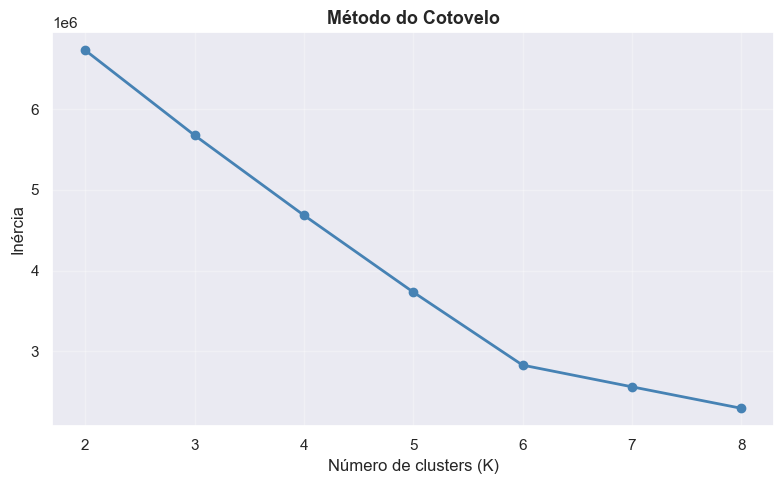

In [56]:
#  Escolha do número de clusters
inertias = []
K_range  = range(2, 9)

for k in K_range:
    print(f"A calcular K={k}...", end=" ", flush=True)
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_if)
    inertias.append(km.inertia_)
    print(f"✓ (inércia={km.inertia_:.0f})")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(K_range), inertias, marker='o', color='steelblue', linewidth=2)
ax.set_title("Método do Cotovelo", fontsize=13, fontweight='bold')
ax.set_xlabel("Número de clusters (K)")
ax.set_ylabel("Inércia")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("kmeans_elbow_contratos.png", dpi=150, bbox_inches='tight')
plt.show()


A calcular K=2... ✓ (CH=539284.22)
A calcular K=3... ✓ (CH=483077.97)
A calcular K=4... ✓ (CH=514458.50)
A calcular K=5... ✓ (CH=596737.31)
A calcular K=6... ✓ (CH=743213.18)
A calcular K=7... ✓ (CH=715371.15)
A calcular K=8... ✓ (CH=713703.06)


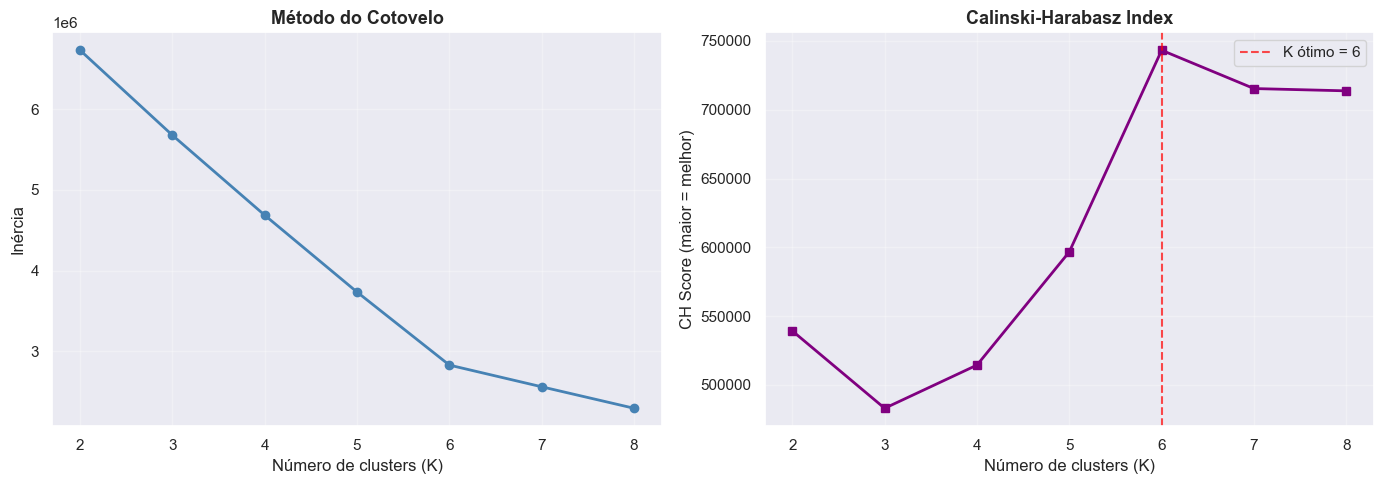

K ótimo (Calinski-Harabasz): 6


In [57]:

inertias  = []
ch_scores = []
K_range   = range(2, 9)

for k in K_range:
    print(f"A calcular K={k}...", end=" ", flush=True)
    km  = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_if)
    inertias.append(km.inertia_)
    ch_scores.append(calinski_harabasz_score(X_if, lbl))
    print(f"✓ (CH={ch_scores[-1]:.2f})")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(K_range), inertias, marker='o', color='steelblue', linewidth=2)
axes[0].set_title("Método do Cotovelo", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Número de clusters (K)")
axes[0].set_ylabel("Inércia")
axes[0].grid(True, alpha=0.3)

axes[1].plot(list(K_range), ch_scores, marker='s', color='purple', linewidth=2)
axes[1].set_title("Calinski-Harabasz Index", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Número de clusters (K)")
axes[1].set_ylabel("CH Score (maior = melhor)")
axes[1].grid(True, alpha=0.3)

# marca o máximo
K_OTIMO = list(K_range)[ch_scores.index(max(ch_scores))]
axes[1].axvline(x=K_OTIMO, color='red', linestyle='--', alpha=0.7, label=f'K ótimo = {K_OTIMO}')
axes[1].legend()

plt.tight_layout()
plt.savefig("kmeans_elbow_ch_contratos.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"K ótimo (Calinski-Harabasz): {K_OTIMO}")


A calcular K=2... ✓ (DB=1.2369)
A calcular K=3... ✓ (DB=1.1540)
A calcular K=4... ✓ (DB=1.0431)
A calcular K=5... ✓ (DB=0.9267)
A calcular K=6... ✓ (DB=0.7311)
A calcular K=7... ✓ (DB=0.7605)
A calcular K=8... ✓ (DB=0.7557)


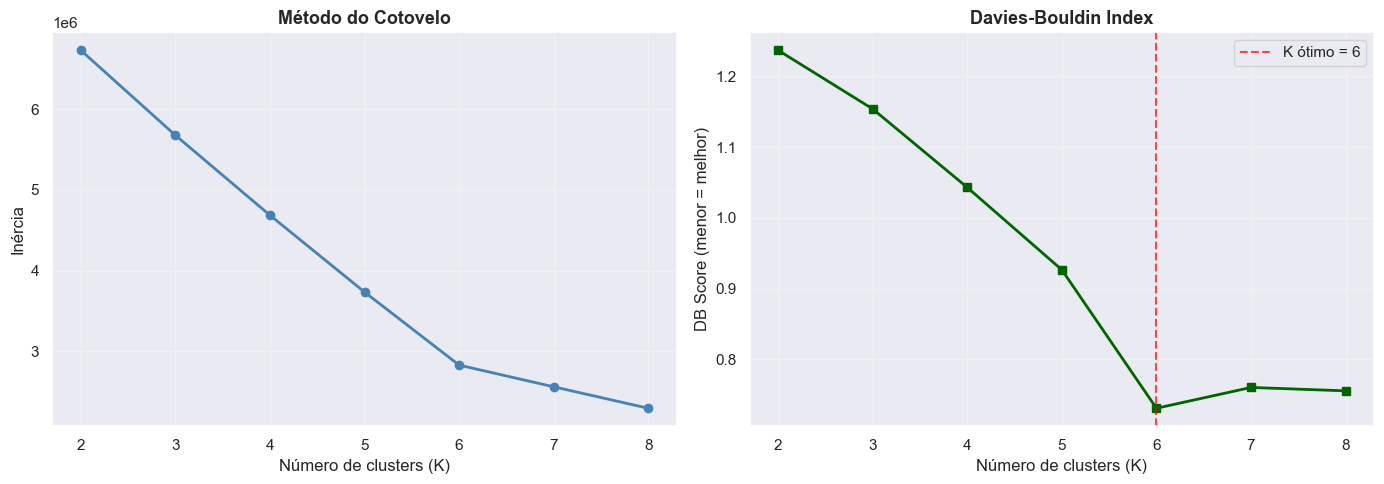

K ótimo (Davies-Bouldin): 6


In [58]:
inertias = []
db_scores = []
K_range  = range(2, 9)

for k in K_range:
    print(f"A calcular K={k}...", end=" ", flush=True)
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_if)
    inertias.append(km.inertia_)
    db_scores.append(davies_bouldin_score(X_if, lbl))
    print(f"✓ (DB={db_scores[-1]:.4f})")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(K_range), inertias, marker='o', color='steelblue', linewidth=2)
axes[0].set_title("Método do Cotovelo", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Número de clusters (K)")
axes[0].set_ylabel("Inércia")
axes[0].grid(True, alpha=0.3)

axes[1].plot(list(K_range), db_scores, marker='s', color='darkgreen', linewidth=2)
axes[1].set_title("Davies-Bouldin Index", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Número de clusters (K)")
axes[1].set_ylabel("DB Score (menor = melhor)")
axes[1].grid(True, alpha=0.3)

# marca o mínimo
K_OTIMO = list(K_range)[db_scores.index(min(db_scores))]
axes[1].axvline(x=K_OTIMO, color='red', linestyle='--', alpha=0.7, label=f'K ótimo = {K_OTIMO}')
axes[1].legend()

plt.tight_layout()
plt.savefig("kmeans_elbow_db_contratos.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"K ótimo (Davies-Bouldin): {K_OTIMO}")

In [59]:
#k-means com 6 clusters
km_final = KMeans(n_clusters=6, random_state=42, n_init=10)
df_if["cluster_km"] = km_final.fit_predict(X_if)


In [60]:
#identificação de qual cluster o contrato pertence
df = df.merge(
    df_if[["idcontrato", "cluster_km"]],
    on="idcontrato",
    how="left"
)

### Análise dos clusters

In [61]:
df['cluster_km'].value_counts()

cluster_km
3.0    910345
1.0    592305
0.0    129105
2.0     68328
4.0     52123
5.0      7386
Name: count, dtype: int64

In [62]:
#ano mais frequente
df.groupby('cluster_km')['Ano'].agg(lambda x: x.value_counts().idxmax())

cluster_km
0.0    2025
1.0    2025
2.0    2023
3.0    2024
4.0    2018
5.0    2025
Name: Ano, dtype: int64

In [63]:
#setor mais frequente
df.groupby('cluster_km')['setor_cpv'].agg(lambda x: x.value_counts().idxmax())

cluster_km
0.0    79.0
1.0    33.0
2.0    33.0
3.0    33.0
4.0    33.0
5.0    45.0
Name: setor_cpv, dtype: float64

In [64]:
df_if.groupby('cluster_km')['setor_cpv'].agg(
    lambda x: x.value_counts().head(3).index.tolist()
)

cluster_km
0    [79.0, 72.0, 50.0]
1    [33.0, 45.0, 15.0]
2    [33.0, 45.0, 15.0]
3    [33.0, 79.0, 50.0]
4    [33.0, 45.0, 85.0]
5     [45.0, 33.0, 9.0]
Name: setor_cpv, dtype: object

In [65]:
perc = (
    df.groupby('cluster_km')['janela_eleicoes']
      .value_counts(normalize=True)
      .mul(100)
      .rename('percentagem')
      .reset_index()
)

#filtrar só os "Sim" (3 meses antes + depois)
perc_sim = (
    perc[perc['janela_eleicoes'].isin(['3 meses antes', '3 meses depois'])]
    .groupby('cluster_km')['percentagem']
    .sum().round(1)
    .reset_index(name='perc_sim')
)

print(perc_sim)

   cluster_km  perc_sim
0         0.0      38.0
1         1.0      38.1
2         2.0      38.5
3         3.0      36.1
4         4.0      26.4
5         5.0      38.2


In [66]:
(df.groupby('cluster_km')['is_ajuste_direto'].mean() * 100).round(1)

cluster_km
0.0     42.5
1.0      0.0
2.0      0.8
3.0    100.0
4.0     61.9
5.0      7.8
Name: is_ajuste_direto, dtype: float64

In [67]:
df.groupby('cluster_km')['num_concorrentes'].mean().round(0)


cluster_km
0.0     1.0
1.0     1.0
2.0    17.0
3.0     0.0
4.0     1.0
5.0     4.0
Name: num_concorrentes, dtype: float64

In [68]:
df["dataPublicacao"]

0         2009-06-05
1         2015-01-02
2         2015-01-02
3         2015-01-02
4         2015-01-02
             ...    
1803488   2024-08-08
1803489   2024-04-15
1803490   2024-07-17
1803491   2024-11-07
1803492   2025-01-14
Name: dataPublicacao, Length: 1803493, dtype: datetime64[us]

In [69]:
df.groupby('cluster_km')['dias_publicacao_decisao'].mean().round(1)

cluster_km
0.0     53.0
1.0     58.4
2.0     88.8
3.0     53.2
4.0    763.2
5.0     99.4
Name: dias_publicacao_decisao, dtype: float64

In [70]:
df.groupby('cluster_km')['racio_preco_prazo'].mean().round(1)

cluster_km
0.0      92.0
1.0     851.9
2.0     396.8
3.0    1192.2
4.0    1037.0
5.0    8709.8
Name: racio_preco_prazo, dtype: float64

In [71]:
df.groupby('cluster_km')['prazoExecucao'].mean().round(1)

cluster_km
0.0    948.6
1.0    184.4
2.0    319.2
3.0    127.7
4.0    242.3
5.0    573.6
Name: prazoExecucao, dtype: float64

In [72]:
summary = pd.DataFrame({
    'Nº de Observações': df['cluster_km'].value_counts().sort_index(),
    'Ano':               df.groupby('cluster_km')['Ano'].agg(lambda x: x.value_counts().idxmax()),
    'Ano %':             (df.groupby('cluster_km')['Ano']                          # ← novo
                            .agg(lambda x: x.value_counts(normalize=True).max() * 100)
                            .round(1)),
    'Setor':             df.groupby('cluster_km')['setor_cpv'].agg(lambda x: x.value_counts().idxmax()),
    'Setor %':           (df.groupby('cluster_km')['setor_cpv']                    # ← novo
                            .agg(lambda x: x.value_counts(normalize=True).max() * 100)
                            .round(1)),
    'Eleição %':         (df.groupby('cluster_km')['janela_eleicoes']
                            .value_counts(normalize=True)
                            .mul(100)
                            .rename('pct')
                            .reset_index()
                            .query("janela_eleicoes in ['3 meses antes', '3 meses depois']")
                            .groupby('cluster_km')['pct']
                            .sum()
                            .round(1)),
    'Ajuste Direto %':   (df.groupby('cluster_km')['is_ajuste_direto'].mean() * 100).round(0),
    'Nº de Concorrentes': df.groupby('cluster_km')['num_concorrentes'].mean().round(0).astype(int),
    'D-P':               df.groupby('cluster_km')['dias_publicacao_decisao'].mean().round(0),
    'Preco/Prazo':        df.groupby('cluster_km')['racio_preco_prazo'].mean().round(0),
    'Prazo':             df.groupby('cluster_km')['prazoExecucao'].mean().round(0),
})

summary.index.name = 'Cluster'
summary

,Nº de Observações,Ano,Ano %,Setor,Setor %,Eleição %,Ajuste Direto %,Nº de Concorrentes,D-P,Preco/Prazo,Prazo
Cluster,,,,,,,,,,,
0.0,129105,2025,14.0,79.0,13.5,38.0,42.0,1,53.0,92.0,949.0
1.0,592305,2025,17.5,33.0,29.5,38.1,0.0,1,58.0,852.0,184.0
2.0,68328,2023,19.7,33.0,70.2,38.5,1.0,17,89.0,397.0,319.0
3.0,910345,2024,11.1,33.0,27.8,36.1,100.0,0,53.0,1192.0,128.0
4.0,52123,2018,14.5,33.0,42.6,26.4,62.0,1,763.0,1037.0,242.0
5.0,7386,2025,15.8,45.0,40.9,38.2,8.0,4,99.0,8710.0,574.0


In [75]:
def plot_centroids_clusters(
    df,
    x_var,
    y_var,
    cluster_col='cluster_km',
    name_map=None,
    title="Centroides dos Clusters",
    palette_name="Set2"
):
    # Calcular centroides
    centroids = df.groupby(cluster_col).agg({
        x_var: 'mean',
        y_var: 'mean',
        cluster_col: 'size'
    }).rename(columns={cluster_col: 'n_contratos'}).reset_index()

    # Mapear nomes dos clusters (opcional)
    if name_map is not None:
        centroids['nome_cluster'] = centroids[cluster_col].map(name_map)
    else:
        centroids['nome_cluster'] = centroids[cluster_col].astype(str)

    # Tamanho das bolhas
    centroids['bubble_size'] = np.interp(
        centroids['n_contratos'],
        (centroids['n_contratos'].min(), centroids['n_contratos'].max()),
        (500, 4000)
    )

    # Estilo
    sns.set_theme(style="whitegrid")
    fig, ax = plt.subplots(figsize=(13, 8))

    palette = sns.color_palette(palette_name, len(centroids))

    # Scatter
    for i, row in centroids.iterrows():
        ax.scatter(
            row[x_var],
            row[y_var],
            s=row['bubble_size'],
            color=palette[i],
            edgecolor='black',
            linewidth=1.5,
            alpha=0.85
        )

    ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel(x_var, fontsize=12)
    ax.set_ylabel(y_var, fontsize=12)

    ax.grid(True, linestyle='--', alpha=0.4)
    sns.despine()

    # Legenda com bolinhas pequenas
    handles = [
        Line2D(
            [0], [0],
            marker='o',
            color='w',
            label=row['nome_cluster'],
            markerfacecolor=palette[i],
            markeredgecolor='black',
            markersize=8
        )
        for i, row in centroids.iterrows()
    ]

    ax.legend(
        handles=handles,
        title="Clusters",
        bbox_to_anchor=(1.02, 1),
        loc='upper left',
        frameon=True
    )

    plt.tight_layout()
    plt.show()


In [76]:
mapa_nomes = {
    0: "Serviços a empresas",
    1: "Farmacêuticos 2025",
    2: "Farmacêuticos 2023",
    3: "Farmacêuticos 2024",
    4: "Farmacêuticos 2018",
    5: "Construção"
}

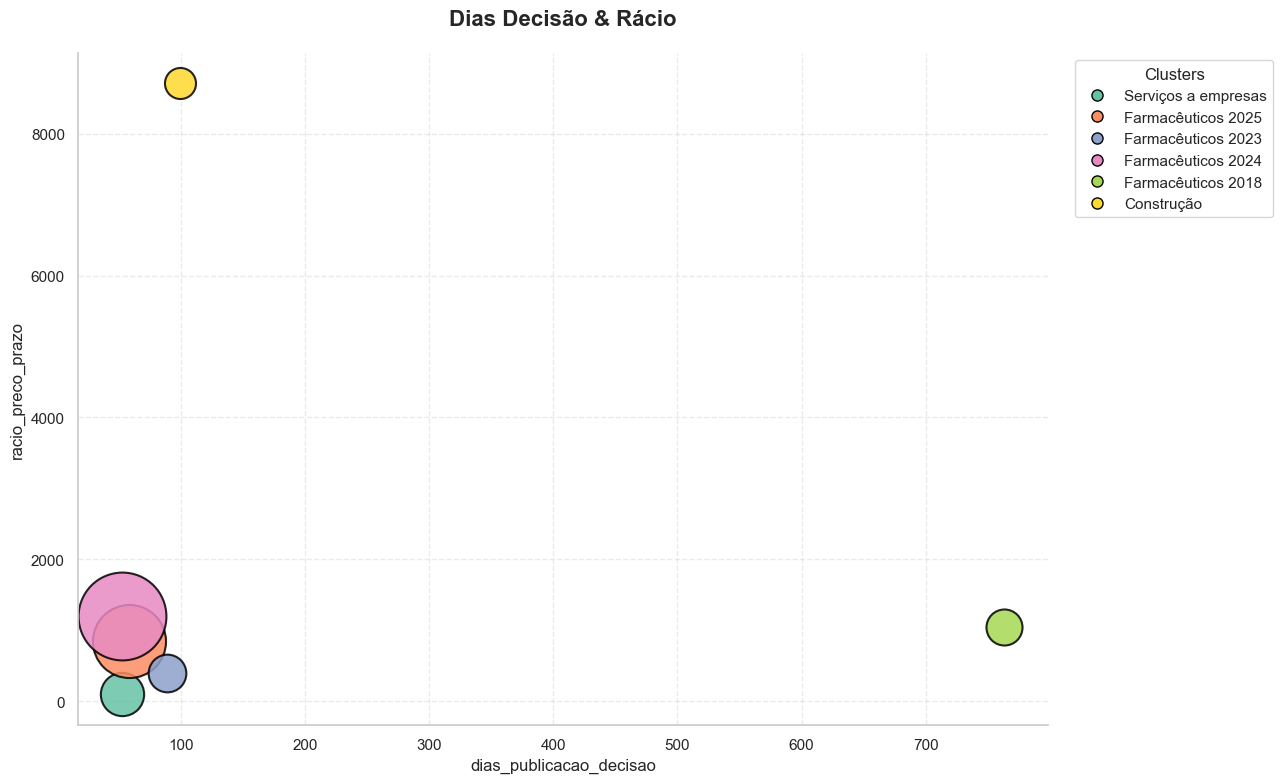

In [77]:
plot_centroids_clusters(
    df,
    x_var='dias_publicacao_decisao',
    y_var='racio_preco_prazo',
    name_map=mapa_nomes,
    title="Dias Decisão & Rácio"
)


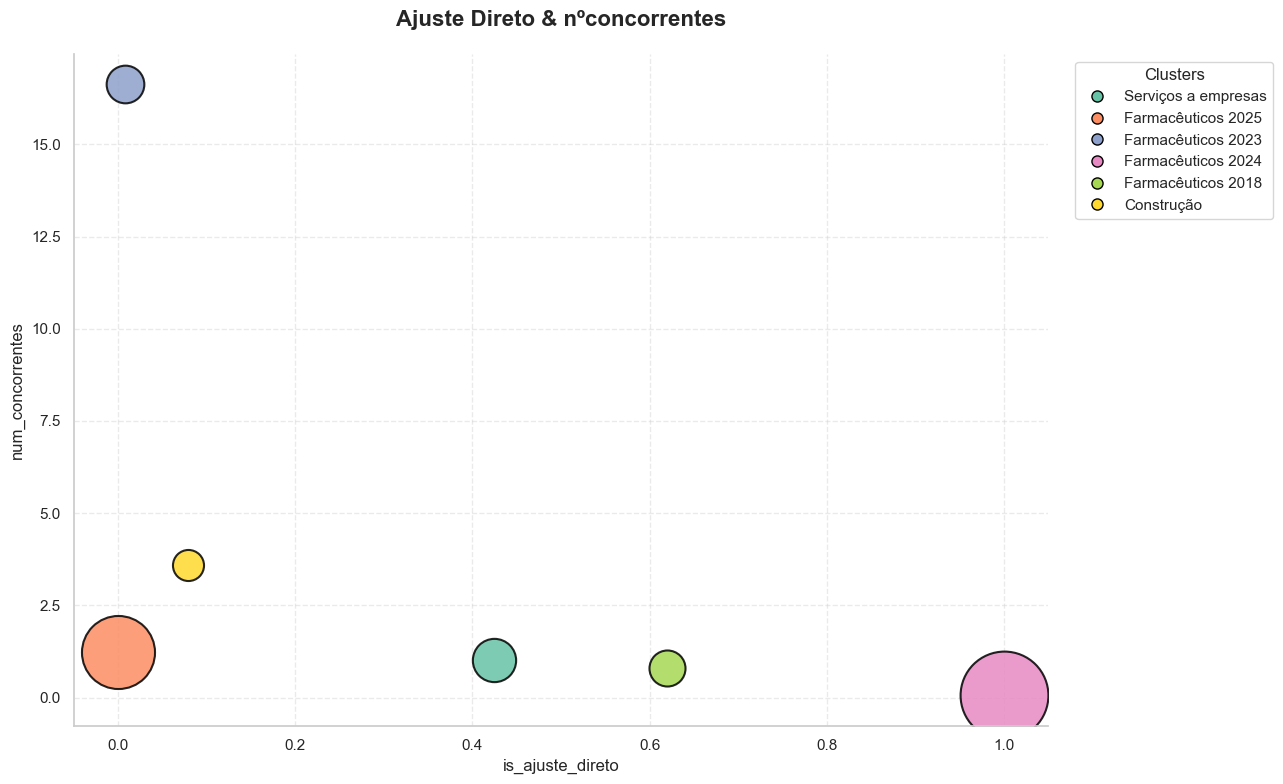

In [78]:
plot_centroids_clusters(
    df,
    x_var='is_ajuste_direto',
    y_var='num_concorrentes',
    name_map=mapa_nomes,
    title="Ajuste Direto & nºconcorrentes"
)


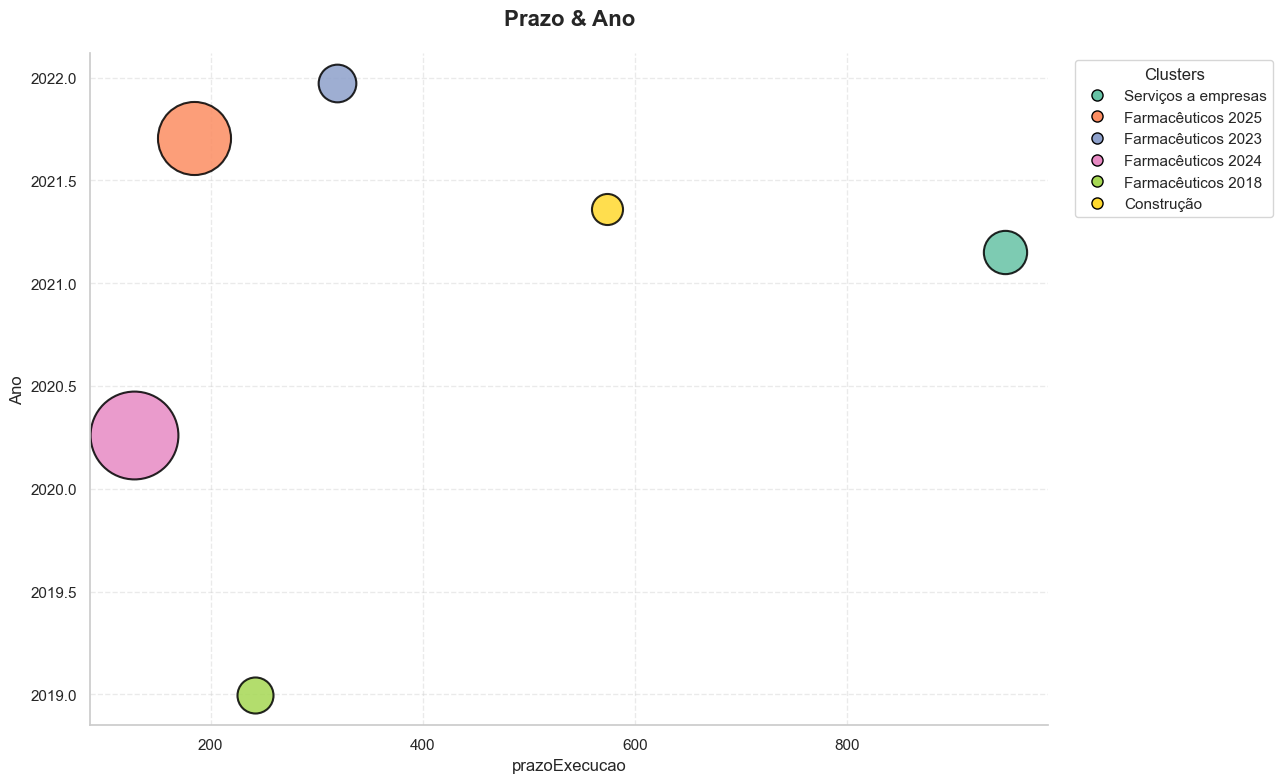

In [79]:
plot_centroids_clusters(
    df,
    x_var='prazoExecucao',
    y_var='Ano',
    name_map=mapa_nomes,
    title="Prazo & Ano"
)
#nao sei como fazer para incluir a janela de eleições por isso ya este par ta meio podre.

**KMEANS 3 CLUSTERS**

In [80]:
km_3 = KMeans(n_clusters=3, random_state=42, n_init=10)
df_if["cluster_km_3"] = km_3.fit_predict(X_if)


In [81]:
df3 = df.merge(
    df_if[["idcontrato", "cluster_km_3"]],
    on="idcontrato",
    how="left"
)

In [82]:
df3['cluster_km_3'].value_counts()

cluster_km_3
0.0    997551
1.0    676943
2.0     85098
Name: count, dtype: int64

In [83]:
summary = pd.DataFrame({
    'Nº de Observações': df3['cluster_km_3'].value_counts().sort_index(),
    'Ano':               df3.groupby('cluster_km_3')['Ano'].agg(lambda x: x.value_counts().idxmax()),
    'Ano %':             (df3.groupby('cluster_km_3')['Ano']
                            .agg(lambda x: x.value_counts(normalize=True).max() * 100)
                            .round(1)),
    'Setor':             df3.groupby('cluster_km_3')['setor_cpv'].agg(lambda x: x.value_counts().idxmax()),
    'Setor %':           (df3.groupby('cluster_km_3')['setor_cpv']
                            .agg(lambda x: x.value_counts(normalize=True).max() * 100)
                            .round(1)),
    'Eleição %':         (df3.groupby('cluster_km_3')['janela_eleicoes']
                            .value_counts(normalize=True)
                            .mul(100)
                            .rename('pct')
                            .reset_index()
                            .query("janela_eleicoes in ['3 meses antes', '3 meses depois']")
                            .groupby('cluster_km_3')['pct']
                            .sum()
                            .round(1)),
    'Ajuste Direto %':   (df3.groupby('cluster_km_3')['is_ajuste_direto'].mean() * 100).round(0),
    'Nº de Concorrentes': df3.groupby('cluster_km_3')['num_concorrentes'].mean().round(0).astype(int),
    'D-P':               df3.groupby('cluster_km_3')['dias_publicacao_decisao'].mean().round(0),
    'Preco/Prazo':        df3.groupby('cluster_km_3')['racio_preco_prazo'].mean().round(0),
    'Prazo':             df3.groupby('cluster_km_3')['prazoExecucao'].mean().round(0),
})

summary.index.name = 'Cluster'
summary

,Nº de Observações,Ano,Ano %,Setor,Setor %,Eleição %,Ajuste Direto %,Nº de Concorrentes,D-P,Preco/Prazo,Prazo
Cluster,,,,,,,,,,,
0.0,997551,2024,10.9,33.0,26.9,35.8,100.0,0,76.0,1126.0,176.0
1.0,676943,2025,17.0,33.0,27.9,38.0,0.0,1,77.0,781.0,264.0
2.0,85098,2023,18.2,33.0,60.4,38.2,1.0,15,103.0,1116.0,377.0


### KMEANS 7 CLUSTERS

In [84]:
km_7 = KMeans(n_clusters=7, random_state=42, n_init=10)
df_if["cluster_km_7"] = km_7.fit_predict(X_if)

In [85]:
df7 = df.merge(
    df_if[["idcontrato", "cluster_km_7"]],
    on="idcontrato",
    how="left"
)

In [86]:
df7['cluster_km_7'].value_counts()

cluster_km_7
1.0    879954
2.0    576697
5.0    128383
0.0     85144
3.0     68172
6.0     13838
4.0      7404
Name: count, dtype: int64

In [87]:
summary = pd.DataFrame({
    'Nº de Observações': df7['cluster_km_7'].value_counts().sort_index(),
    'Ano':               df7.groupby('cluster_km_7')['Ano'].agg(lambda x: x.value_counts().idxmax()),
    'Ano %':             (df7.groupby('cluster_km_7')['Ano']
                            .agg(lambda x: x.value_counts(normalize=True).max() * 100)
                            .round(1)),
    'Setor':             df7.groupby('cluster_km_7')['setor_cpv'].agg(lambda x: x.value_counts().idxmax()),
    'Setor %':           (df7.groupby('cluster_km_7')['setor_cpv']
                            .agg(lambda x: x.value_counts(normalize=True).max() * 100)
                            .round(1)),
    'Eleição %':         (df7.groupby('cluster_km_7')['janela_eleicoes']
                            .value_counts(normalize=True)
                            .mul(100)
                            .rename('pct')
                            .reset_index()
                            .query("janela_eleicoes in ['3 meses antes', '3 meses depois']")
                            .groupby('cluster_km_7')['pct']
                            .sum()
                            .round(1)),
    'Ajuste Direto %':   (df7.groupby('cluster_km_7')['is_ajuste_direto'].mean() * 100).round(0),
    'Nº de Concorrentes': df7.groupby('cluster_km_7')['num_concorrentes'].mean().round(0).astype(int),
    'D-P':               df7.groupby('cluster_km_7')['dias_publicacao_decisao'].mean().round(0),
    'Preco/Prazo':        df7.groupby('cluster_km_7')['racio_preco_prazo'].mean().round(0),
    'Prazo':             df7.groupby('cluster_km_7')['prazoExecucao'].mean().round(0),
})

summary.index.name = 'Cluster'
summary

,Nº de Observações,Ano,Ano %,Setor,Setor %,Eleição %,Ajuste Direto %,Nº de Concorrentes,D-P,Preco/Prazo,Prazo
Cluster,,,,,,,,,,,
0.0,85144,2018,12.4,33.0,42.3,25.3,64.0,1,448.0,838.0,221.0
1.0,879954,2025,11.3,33.0,27.5,36.6,100.0,0,44.0,1211.0,126.0
2.0,576697,2025,17.8,33.0,29.0,38.5,0.0,1,50.0,852.0,183.0
3.0,68172,2023,19.7,33.0,70.3,38.4,1.0,17,89.0,396.0,320.0
4.0,7404,2025,15.9,45.0,40.9,38.2,8.0,4,99.0,8697.0,574.0
5.0,128383,2025,14.1,79.0,13.5,38.0,42.0,1,51.0,92.0,950.0
6.0,13838,2018,21.8,33.0,37.0,23.3,60.0,1,1268.0,1171.0,263.0


## DBSCAN

In [105]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1803493 entries, 0 to 1803492
Data columns (total 39 columns):
 #   Column                    Dtype         
---  ------                    -----         
 0   idcontrato                int64         
 1   tipoContrato              str           
 2   idprocedimento            int64         
 3   tipoprocedimento          str           
 4   objectoContrato           str           
 5   descContrato              str           
 6   adjudicante               str           
 7   adjudicatarios            str           
 8   dataPublicacao            datetime64[us]
 9   dataCelebracaoContrato    str           
 10  precoContratual           float64       
 11  CPV                       str           
 12  prazoExecucao             int64         
 13  LocalExecucao             str           
 14  fundamentacao             str           
 15  ProcedimentoCentralizado  str           
 16  DescrAcordoQuadro         str           
 17  dataDecisaoAdjudica

#### Criação de uma amostra que representa a base de dados

In [89]:
# 15% de cada cluster gerado no k-means com k=6
FRAC = 0.15
amostra = df.groupby("cluster_km", group_keys=False).sample(frac=FRAC, random_state=42)

# Verificação
verificacao = pd.DataFrame({
    'N original':  df['cluster_km'].value_counts().sort_index(),
    'N amostra':   amostra['cluster_km'].value_counts().sort_index(),
    '% recolhida': (amostra['cluster_km'].value_counts().sort_index() /
                    df['cluster_km'].value_counts().sort_index() * 100).round(1)
})
print(verificacao)
print(f"\nTotal amostra: {len(amostra):,} observações")

            N original  N amostra  % recolhida
cluster_km                                    
0.0             129105      19366         15.0
1.0             592305      88846         15.0
2.0              68328      10249         15.0
3.0             910345     136552         15.0
4.0              52123       7818         15.0
5.0               7386       1108         15.0

Total amostra: 263,939 observações


In [90]:
#features
FEAT_IF = ["precoContratual_2025", "prazoExecucao", "num_concorrentes",
           "is_ajuste_direto", "dias_publicacao_decisao"]

amostra_clean = amostra[FEAT_IF].dropna()
idx_validos   = amostra_clean.index

#garantia de que estão normalizadas
scaler    = StandardScaler()
X_amostra = scaler.fit_transform(amostra_clean)

print(f"Amostra para DBSCAN: {len(amostra_clean):,} observações")

Amostra para DBSCAN: 263,939 observações


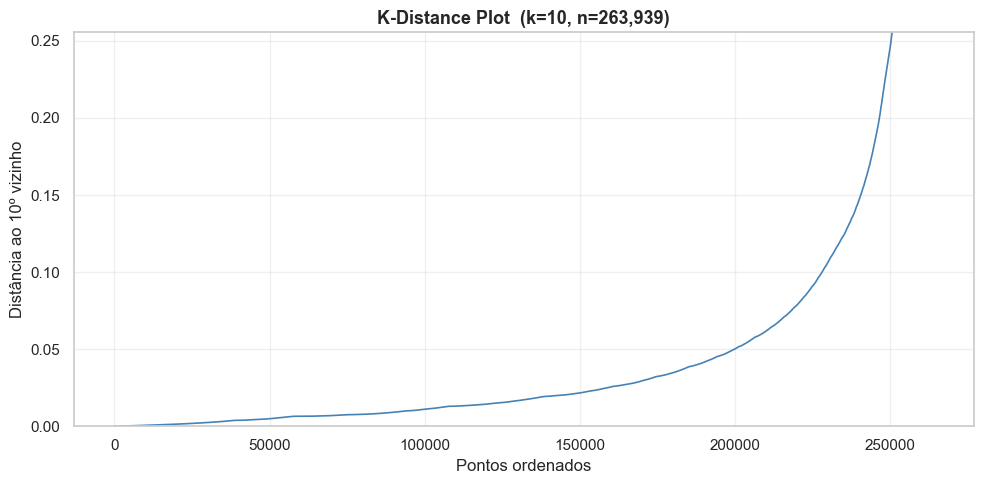

In [91]:
# Escolhea do eps
MIN_PTS = 10

nbrs = NearestNeighbors(n_neighbors=MIN_PTS, algorithm="ball_tree", n_jobs=-1)
nbrs.fit(X_amostra)
distances, _ = nbrs.kneighbors(X_amostra)
k_dists = np.sort(distances[:, -1])
# percentis para cortar os extremos
p95 = np.percentile(k_dists, 95)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_dists, color="steelblue", linewidth=1.2)
ax.set_ylim(0, p95)
ax.set_title(f"K-Distance Plot  (k={MIN_PTS}, n={len(X_amostra):,})",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Pontos ordenados")
ax.set_ylabel(f"Distância ao {MIN_PTS}º vizinho")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [92]:
#DBSCAN
db = DBSCAN(
    eps=0.08,
    min_samples=10,
    algorithm="ball_tree",
    n_jobs=-1
)

print("A correr DBSCAN...")
labels = db.fit_predict(X_amostra)
print("✓ Concluído")

A correr DBSCAN...
✓ Concluído


In [93]:
# adição dos resultados à amostra
amostra = amostra.copy()
amostra.loc[idx_validos, "cluster_db"] = labels

#Resultados do clustering
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise    = (labels == -1).sum()
pct_noise  = n_noise / len(labels) * 100

print(f"\nClusters encontrados : {n_clusters}")
print(f"Ruído (outliers -1)  : {n_noise:,}  ({pct_noise:.1f}%)")
print(f"\n{amostra['cluster_db'].value_counts().rename({-1.0: 'RUÍDO (-1)'}).head(15)}")


Clusters encontrados : 294
Ruído (outliers -1)  : 35,865  (13.6%)

cluster_db
1.0           139080
5.0            50147
RUÍDO (-1)     35865
54.0            9198
59.0            6689
57.0            2879
0.0             2101
60.0            2076
55.0            1351
56.0            1082
4.0              802
233.0            783
3.0              540
234.0            481
58.0             463
Name: count, dtype: int64


### Análise do ruído

In [100]:

ruido = amostra[amostra["cluster_db"] == -1]

summary_ruido = pd.DataFrame({
    'Nº de Observações': [len(ruido)],

    'Ano': [ruido['Ano'].value_counts().idxmax()],
    'Ano %': [(ruido['Ano'].value_counts(normalize=True).max() * 100).round(1)],

    'Setor': [ruido['setor_cpv'].value_counts().idxmax()],
    'Setor %': [(ruido['setor_cpv'].value_counts(normalize=True).max() * 100).round(1)],

    'Eleição %': [(
        ruido['janela_eleicoes']
        .isin(['3 meses antes', '3 meses depois'])
        .mean() * 100
    ).round(1)],

    'Ajuste Direto %': [(ruido['is_ajuste_direto'].mean() * 100).round(1)],

    'Nº de Concorrentes': [ruido['num_concorrentes'].mean().round(0)],

    'D-P': [ruido['dias_publicacao_decisao'].mean().round(0)],

    'Preco/Prazo': [ruido['racio_preco_prazo'].mean().round(0)],

    'Prazo': [ruido['prazoExecucao'].mean().round(0)],
})

summary_ruido.index = ['Ruído']

summary_ruido

,Nº de Observações,Ano,Ano %,Setor,Setor %,Eleição %,Ajuste Direto %,Nº de Concorrentes,D-P,Preco/Prazo,Prazo
Ruído,35865,2023,12.3,33.0,32.8,34.6,21.7,5.0,205.0,1788.0,368.0


In [98]:
# IDs dos contratos em cada dataframe
ids_ruido = set(amostra.loc[amostra["cluster_db"] == -1, "idcontrato"])
ids_outliers = set(df_outliers["idcontrato"])

# interseção
ids_comuns = ids_ruido.intersection(ids_outliers)

# número de observações em comum
n_comuns = len(ids_comuns)

print(f"Nº de contratos presentes tanto no ruído quanto nos outliers: {n_comuns}")

Nº de contratos presentes tanto no ruído quanto nos outliers: 8458


In [99]:
#criação de um dataframe com os contratos considerados pelas duas abordagens
comuns_df = df_outliers[df_outliers["idcontrato"].isin(ids_comuns)]

### Análise dos contratos mais suspeitos

In [104]:
summary_comuns = pd.DataFrame({
    'Nº de Observações': [len(comuns_df)],

    'Ano': [comuns_df['Ano'].value_counts().idxmax()],
    'Ano %': [(comuns_df['Ano'].value_counts(normalize=True).max() * 100).round(1)],

    'Setor': [comuns_df['setor_cpv'].value_counts().idxmax()],
    'Setor %': [(comuns_df['setor_cpv'].value_counts(normalize=True).max() * 100).round(1)],

    'Eleição %': [(
        comuns_df['janela_eleicoes']
        .isin(['3 meses antes', '3 meses depois'])
        .mean() * 100
    ).round(1)],

    'Ajuste Direto %': [(comuns_df['is_ajuste_direto'].mean() * 100).round(1)],

    'Nº de Concorrentes': [comuns_df['num_concorrentes'].mean().round(0)],

    'D-P': [comuns_df['dias_publicacao_decisao'].mean().round(0)],

    'Preco/Prazo': [comuns_df['racio_preco_prazo'].mean().round(0)],

    'Prazo': [comuns_df['prazoExecucao'].mean().round(0)],
})

summary_comuns.index = ['Ruído + Outliers']

summary_comuns

,Nº de Observações,Ano,Ano %,Setor,Setor %,Eleição %,Ajuste Direto %,Nº de Concorrentes,D-P,Preco/Prazo,Prazo
Ruído + Outliers,8458,2025,14.6,33.0,36.4,37.1,24.1,3.0,145.0,5965.0,271.0
